In [35]:
import read_mist_models
import numpy as np
import matplotlib.pyplot as plt
import read_mist_models

In [36]:
iso = read_mist_models.ISO('MIST_iso_69e028e066642 (1)/MIST_iso_69e028e066642.iso')

Reading in: MIST_iso_69e028e066642 (1)/MIST_iso_69e028e066642.iso


In [37]:
print ('version: ', iso.version)
print ('abundances: ', iso.abun)
print ('rotation: ', iso.rot)
print ('ages: ', [round(x,2) for x in iso.ages])
print ('number of ages: ', iso.num_ages)
print ('available columns: ', iso.hdr_list)

version:  {'MIST': '2.5', 'MESA': '11701'}
abundances:  {'Yinit': 0.2722, 'Zinit': 0.0178798, '[Fe/H]': 0.0, '[a/Fe]': 0.0}
rotation:  0.4
ages:  [np.float64(8.0), np.float64(8.5), np.float64(9.0), np.float64(9.5), np.float64(10.0)]
number of ages:  5
available columns:  ['EEP', 'log10_isochrone_age_yr', 'initial_mass', 'star_mass', 'star_mdot', 'he_core_mass', 'c_core_mass', 'o_core_mass', 'log_L', 'log_L_div_Ledd', 'log_LH', 'log_LHe', 'log_LZ', 'log_Teff', 'log_abs_Lgrav', 'log_R', 'log_g', 'log_surf_cell_z', 'surf_avg_omega', 'surf_avg_v_rot', 'surf_num_c12_div_num_o16', 'surf_avg_omega_crit', 'surf_avg_omega_div_omega_crit', 'surf_avg_v_crit', 'surf_avg_v_div_v_crit', 'surf_avg_Lrad_div_Ledd', 'v_div_csound_surf', 'surf_r_equatorial_div_r', 'surf_r_polar_div_r', 'total_angular_momentum', 'grav_dark_L_polar', 'grav_dark_Teff_polar', 'grav_dark_L_equatorial', 'grav_dark_Teff_equatorial', 'surface_h1', 'surface_h2', 'surface_he3', 'surface_he4', 'surface_li7', 'surface_be7', 'surface

In [38]:
for age in (8, 8.5, 9, 9.5, 10):
    age_ind = iso.age_index(age)
    phase = iso.isos[age_ind]['phase']
    print(phase)

[-1. -1. -1. ...  6.  6.  6.]
[-1. -1. -1. ...  6.  6.  6.]
[-1. -1. -1. ...  6.  6.  6.]
[0. 0. 0. ... 6. 6. 6.]
[0. 0. 0. ... 6. 6. 6.]


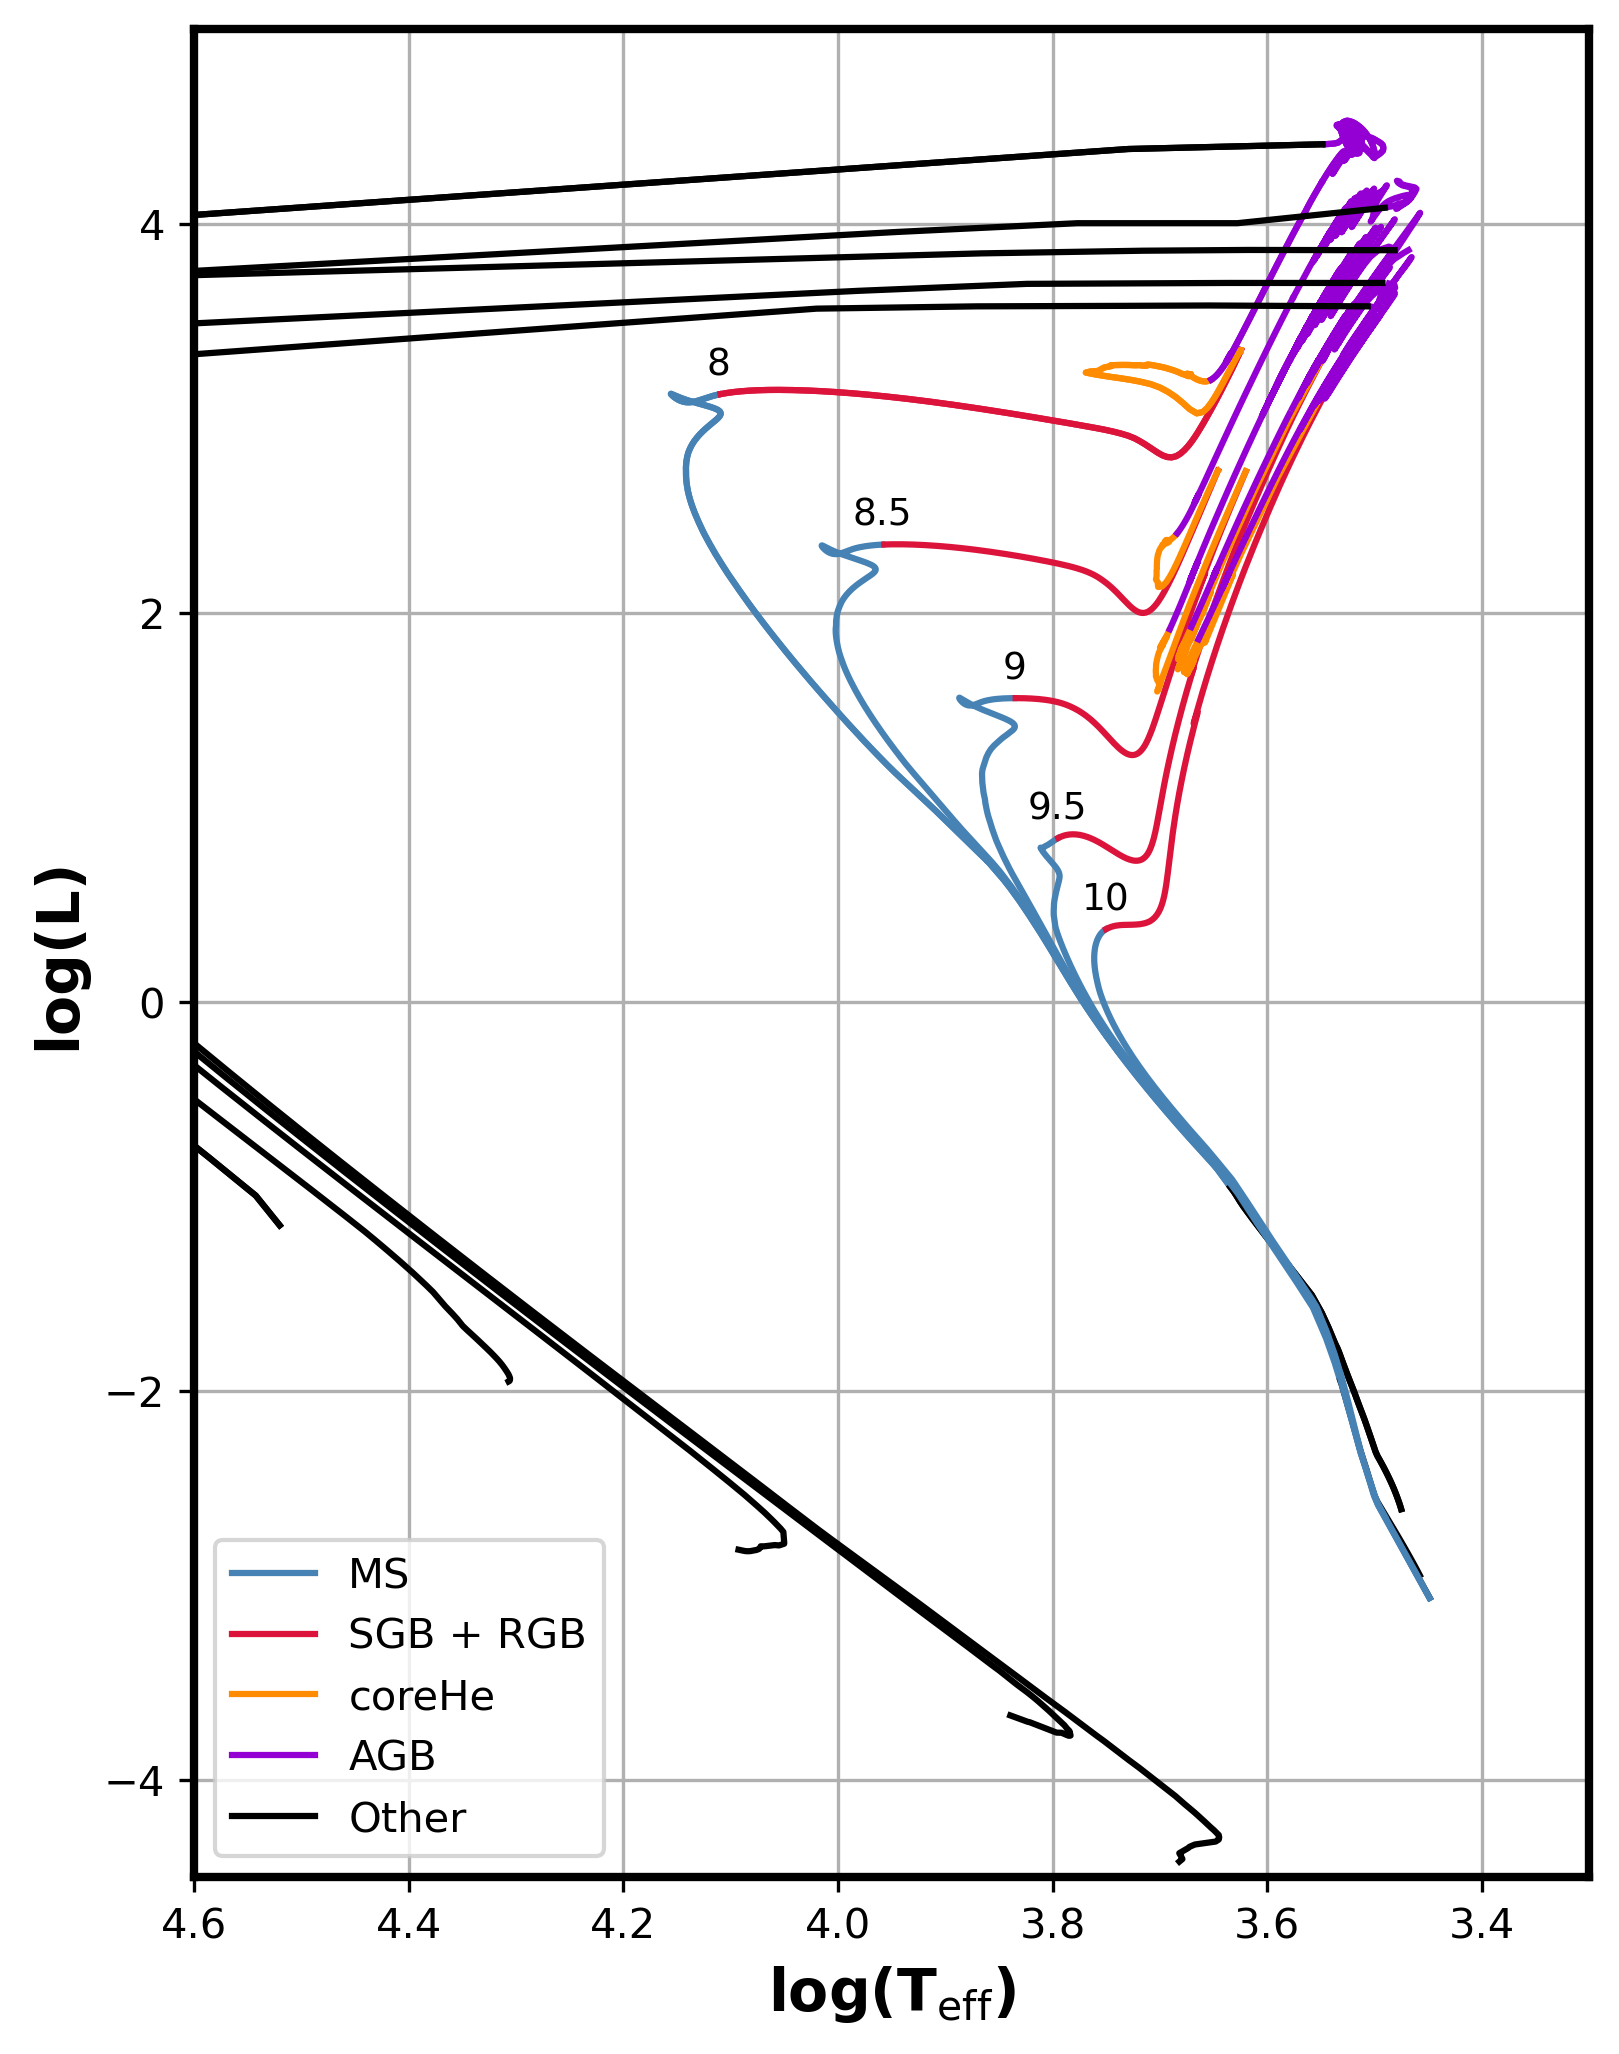

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(6, 8), dpi=300)
for age in (8, 8.5, 9, 9.5, 10):
    age_ind = iso.age_index(age) #returns the index for the desired age
    logTeff = iso.isos[age_ind]['log_Teff']
    logL = iso.isos[age_ind]['log_L']
    phase = iso.isos[age_ind]['phase']

    # base color = black, phase: 0 = MS (green), 2 = SGB + RGB (Red), 3 = coreHe (purple), 4, 5, 6 = AGB (blue)

    # Color mapping by phase
    colors = {
        0: 'steelblue',   # Main Sequence
        2: 'crimson',     # SGB + RGB
        3: 'darkorange',  # Core He burning
        4: 'darkviolet',    # AGB
        5: 'darkviolet'
    }

    labls = {
        0: 'MS',   # Main Sequence
        2: 'SGB + RGB',     # SGB + RGB
        3: 'coreHe',  # Core He burning
        4: 'AGB',    # AGB
        -1: 'Other'
    }

    # Plot each phase separately
    for p in set(phase):
        mask = (phase == p)
        color = colors.get(p, 'black')  # default = black
        labl = labls.get(p, '')
        if age == 8:
            ax.plot(logTeff[mask], logL[mask], color=color, label=labl)
        ax.plot(logTeff[mask], logL[mask], color=color)

    # --- Find MS turnoff (last MS point before phase changes) ---
    ms_mask = (phase == 0)
    ms_indices = np.where(ms_mask)[0]

    if len(ms_indices) > 0:
        turnoff_idx = ms_indices[-1]  # last MS point

        x_to = logTeff[turnoff_idx]
        y_to = logL[turnoff_idx]

        # Add label slightly above
        ax.text(x_to, y_to + 0.1, f'{age}', fontsize=9, ha='center')
    
    ax.set_xlabel(r'log(T$_\text{eff}$)')
    ax.set_ylabel('log(L)')
    ax.axis([4.6, 3.3, -4.5, 5])
    ax.grid(which='both')
    ax.legend()
plt.savefig('2a_isochrones.png')
plt.show()

In [40]:
import numpy as np
import matplotlib.pyplot as plt

In [41]:
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 200
plt.rc('font', family='sans-serif')
plt.rc('axes', labelsize=14)
plt.rc('axes', labelweight='bold')
plt.rc('axes', titlesize=16)
plt.rc('axes', titleweight='bold')
plt.rc('axes', linewidth=2)

In [42]:
sig = np.sqrt(np.log(1/0.2)/1.3)
print(sig)

1.112667588910024


In [43]:
# masses = np.linspace(0.01,100, 10000)
masses = np.logspace(-2, 2, 10000)


def chabrier(m, sigma=sig, m_b=1.0, m_c=0.2, b=2.3):
    lognormal_at_break = m_b**(-1) * np.exp(-(np.log(m_b / m_c))**2 / (2 * sigma**2))
    powerlaw_at_break  = m_b**(-b)
    
    A = lognormal_at_break / powerlaw_at_break

    if m <= m_b:
        n = m**(-1) * np.exp(-(np.log(m / m_c))**2 / (2 * sigma**2))
    else:
        n = A * m**(-b)
    return n

In [44]:
imf = np.array([chabrier(m, sig) for m in masses])

In [45]:
from scipy.integrate import quad

mass_integral = np.trapezoid(masses * imf, masses)

M_total = 1e6  # M_sun
C = M_total / mass_integral

print(f"Normalization constant: C = {C:.4e}")

imf_normalized = C * imf

M_check = np.trapezoid(masses * imf_normalized, masses)
print(f"Total mass check: {M_check:.4e} M_sun")

Normalization constant: C = 6.5353e+05
Total mass check: 1.0000e+06 M_sun


In [46]:
# def chabrier_lum_weighted(m, sigma=sig, m_b=1.0, m_c=0.2, b=2.3):
#     return m**(3.5) * C * chabrier(m, sigma, m_b, m_c, b)

# lum_imf = np.array([chabrier_lum_weighted(m, sig) for m in masses])
# total_lum = np.trapezoid(lum_imf, masses)
# total_lum

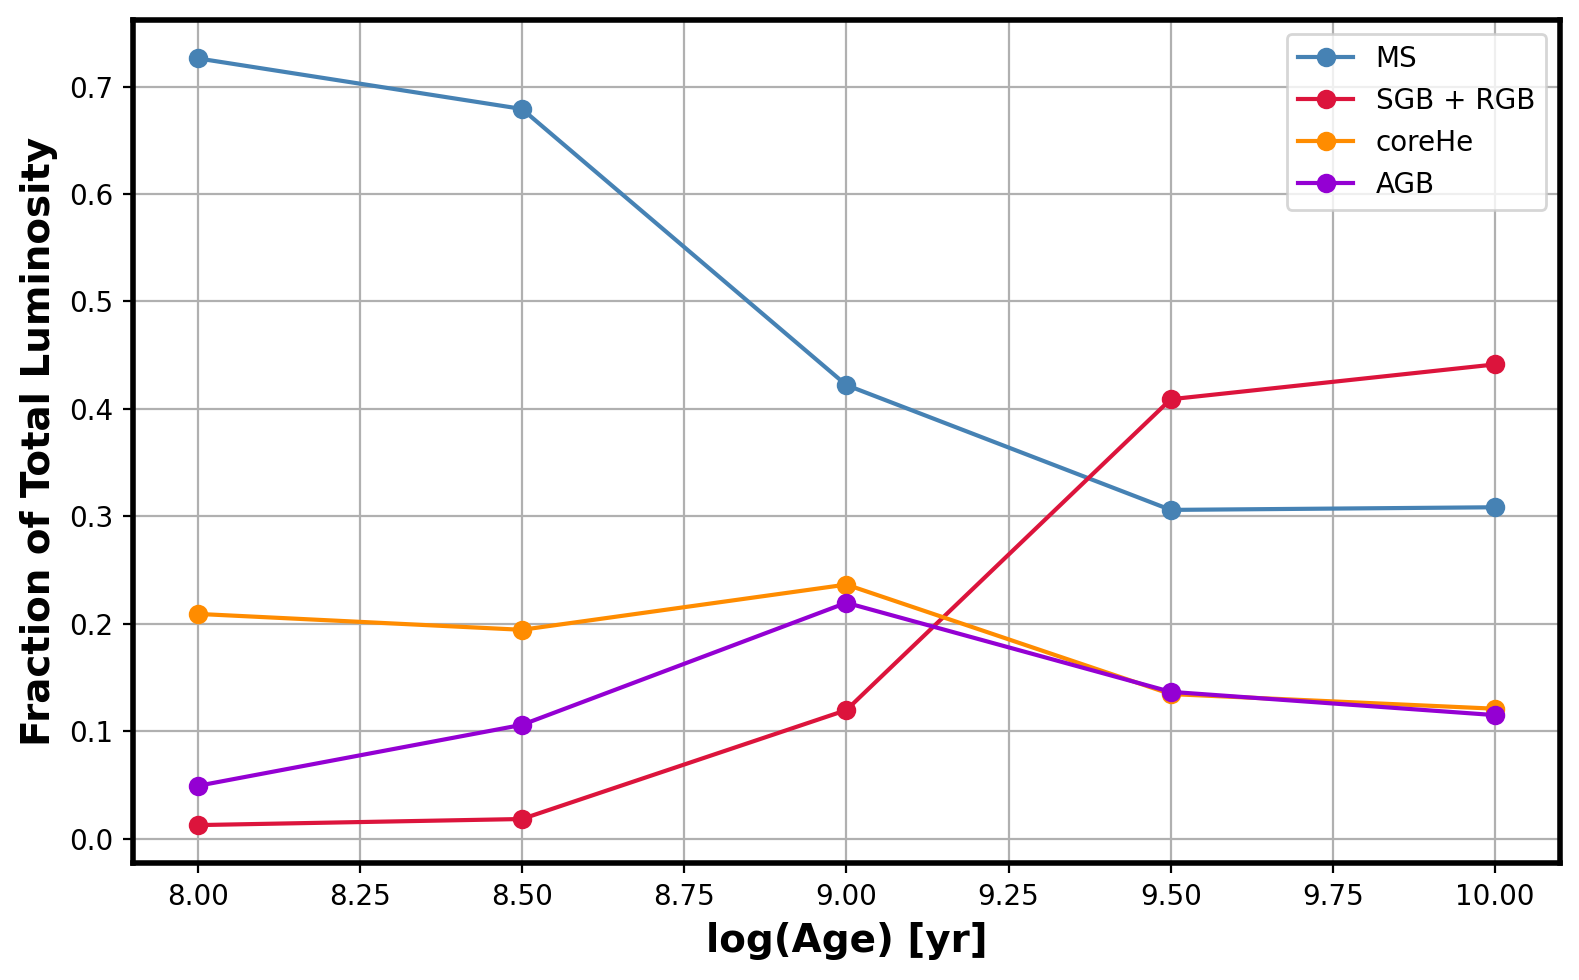

In [47]:
ages = [8, 8.5, 9, 9.5, 10]

# Group phases 4 & 5 both into AGB
phase_groups  = {0: [0], 2: [2], 3: [3], 4: [4, 5]}
phase_labels  = {0: 'MS', 2: 'SGB + RGB', 3: 'coreHe', 4: 'AGB'}
phase_colors  = {0: 'steelblue', 2: 'crimson', 3: 'darkorange', 4: 'darkviolet'}

lum_fractions = {p: [] for p in phase_groups}

from scipy.interpolate import interp1d

for age in ages:
    age_ind = iso.age_index(age)
    logL  = iso.isos[age_ind]['log_L']
    phase = iso.isos[age_ind]['phase']
    mass  = iso.isos[age_ind]['initial_mass']

    L = 10**logL

    # Interpolate IMF at each isochrone mass point
    imf_interp = np.interp(mass, masses, imf)

    # IMF-weighted luminosity density
    Lw = L * imf_interp                        

    total_lum = np.trapezoid(Lw, mass)        

    for p, members in phase_groups.items():
        mask = np.isin(phase, members)
        frac = np.trapezoid(Lw[mask], mass[mask]) / total_lum if mask.any() else 0.0
        lum_fractions[p].append(frac)

fig, ax = plt.subplots()
for p, fracs in lum_fractions.items():
    ax.plot(ages, fracs, marker='o',
            color=phase_colors[p], label=phase_labels[p])

ax.set_xlabel('log(Age) [yr]')
ax.set_ylabel('Fraction of Total Luminosity')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
    

In [48]:
N_total = np.trapezoid(imf_normalized, masses)
print(f"Total number of stars: {N_total:.4e}")

Total number of stars: 1.8575e+06


In [49]:
mass_fractions = {p: [] for p in phase_groups}

for age in ages:
    age_ind = iso.age_index(age)
    logL  = iso.isos[age_ind]['log_L']
    phase = iso.isos[age_ind]['phase']
    mass  = iso.isos[age_ind]['initial_mass']

    # interpolate IMF at each isochrone mass point
    imf_interp = np.interp(mass, masses, imf)

    # IMF-weighted mass density
    mw = mass * imf_interp                        

    total_mass = 1e6     

    for p, members in phase_groups.items():
        mask = np.isin(phase, members)
        frac = np.trapezoid(mw[mask], mass[mask]) / total_mass if mask.any() else 0.0
        mass_fractions[p].append(frac)

print(mass_fractions)

{0: [np.float64(5.926469461454523e-07), np.float64(7.393427018335328e-07), np.float64(7.979916364176191e-07), np.float64(7.13926730051299e-07), np.float64(6.135044136784206e-07)], 2: [np.float64(8.349574555695739e-10), np.float64(1.4246419693813366e-09), np.float64(5.697460785458526e-09), np.float64(1.8773799439802272e-08), np.float64(1.0830751657489684e-08)], 3: [np.float64(1.1885579738990597e-08), np.float64(1.8285446188273598e-08), np.float64(2.6069190043891018e-08), np.float64(3.3248233957378563e-09), np.float64(1.0846289545941968e-09)], 4: [np.float64(7.857513981568935e-10), np.float64(1.2696027405054907e-09), np.float64(1.9143794537019583e-09), np.float64(4.306006642981181e-10), np.float64(1.446588235632695e-10)]}


In [56]:
mass_fractions = {p: [] for p in phase_groups}
mass_in_phases = {p: [] for p in phase_groups}  # store raw integrals too
total_in_age = {age: [] for age in ages} 

for age in ages:
    age_ind = iso.age_index(age)
    phase = iso.isos[age_ind]['phase']
    mass  = iso.isos[age_ind]['initial_mass']

    imf_interp = np.interp(mass, masses, imf)
    mw = mass * imf_interp  # IMF-weighted mass density

    raw = {}
    for p, members in phase_groups.items():
        mask = np.isin(phase, members)
        raw[p] = np.trapezoid(mw[mask], mass[mask]) if mask.any() else 0.0

    total_selected = sum(raw.values())

    for p in phase_groups:
        mass_in_phases[p].append(raw[p] / np.trapezoid(mw, mass) * 1e6)  # M_sun
        mass_fractions[p].append(raw[p] / total_selected)

print(mass_in_phases)

{0: [np.float64(536173.2001225047), np.float64(684998.1050808887), np.float64(740432.7969914925), np.float64(723506.3799912867), np.float64(586333.245327806)], 2: [np.float64(755.3937699849527), np.float64(1319.9251808732204), np.float64(5286.505061713024), np.float64(19025.71104236115), np.float64(10351.074298878853)], 3: [np.float64(10752.994452116427), np.float64(16941.393968539047), np.float64(24188.82907865375), np.float64(3369.4367193504363), np.float64(1036.5924038112423)], 4: [np.float64(710.8765925322344), np.float64(1176.281945158873), np.float64(1776.2959769490258), np.float64(436.3785732266796), np.float64(138.2521064137174)]}
